In [2]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

In [3]:
def img_details(name,img):
    plt.imshow(img)
    plt.title(f"{name}({img.shape})")
    plt.axis('off')
    plt.show()

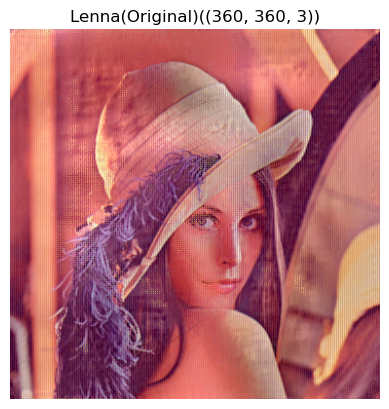

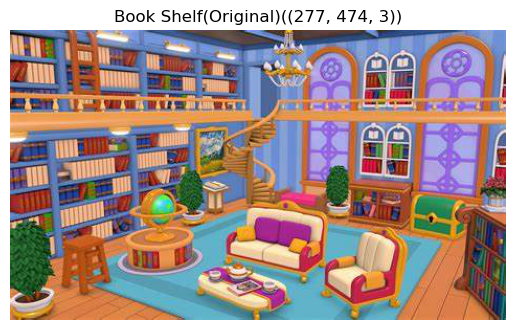

In [4]:
img1 = plt.imread(r"D:\COLLEGE\COMPUTER VISION\IMAGES\Lena")
img2 = plt.imread(r"D:\COLLEGE\COMPUTER VISION\IMAGES\Casual image.jpg")

img_details('Lenna(Original)',img1)
img_details('Book Shelf(Original)',img2)

# RGB TO CMY,HSV

In [5]:
def rgb_to_cmy(img):
    return 1 - img

def rgb_to_hsv(img):
    return cv2.cvtColor(img, cv2.COLOR_RGB2HSV)
    

In [6]:
def rgb_to_hsv_manual(img):
    
    r, g, b = cv2.split(img)
    hsv_img = np.zeros_like(img, dtype=np.float32)

    for i in range(img.shape[0]):  
        for j in range(img.shape[1]):  
            
            R = r[i, j]  
            G = g[i, j]  
            B = b[i, j]

            c_max = max(R, G, B)
            c_min = min(R, G, B)
            delta = c_max - c_min

            if delta == 0:
                H = 0
            elif c_max == R:
                H = 60 * ((G - B) / delta % 6)
            elif c_max == G:
                H = 60 * ((B - R) / delta + 2)
            elif c_max == B:
                H = 60 * ((R - G) / delta + 4)

            S = 0 if c_max == 0 else delta / c_max

            V = c_max

            hsv_img[i, j, 0] = H 
            hsv_img[i, j, 1] = S  
            hsv_img[i, j, 2] = V 

    return hsv_img

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


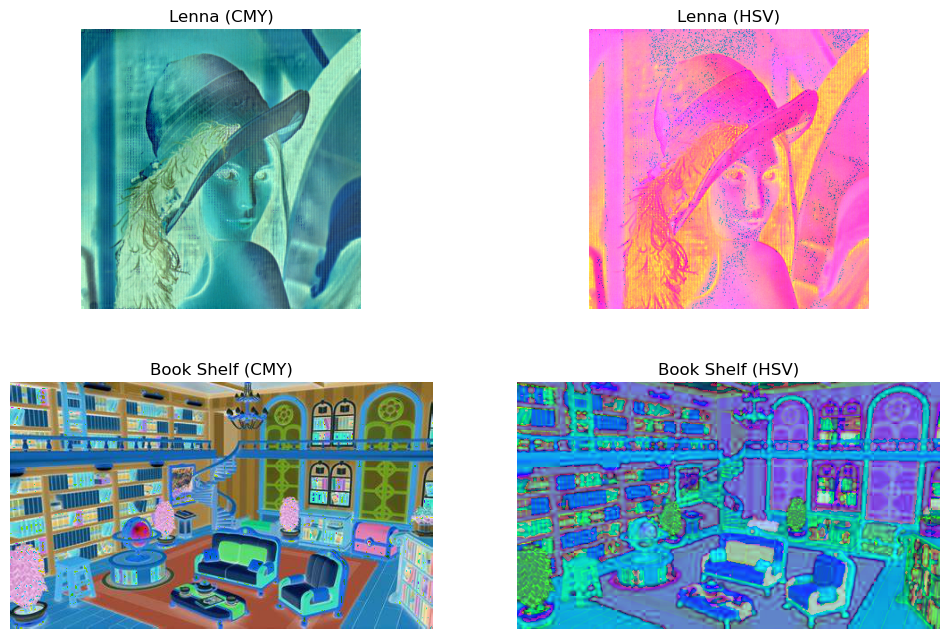

In [9]:
img1_cmy = rgb_to_cmy(img1)
img2_cmy = rgb_to_cmy(img2)

img1_hsv = rgb_to_hsv(img1)
img1_hsv_ = rgb_to_hsv_manual(img1)
img2_hsv = rgb_to_hsv(img2)

fig, axs = plt.subplots(2, 2, figsize=(12, 8))

axs[0, 0].imshow(img1_cmy)
axs[0, 0].set_title('Lenna (CMY)')
axs[0, 1].imshow(img1_hsv)
axs[0, 1].set_title('Lenna (HSV)')

axs[1, 0].imshow(img2_cmy)
axs[1, 0].set_title('Book Shelf (CMY)')
axs[1, 1].imshow(img2_hsv)
axs[1, 1].set_title('Book Shelf (HSV)')

for ax in axs.flat:
    ax.axis('off')

plt.show()

# Separate Channels for RGB,HSV,CMY

In [47]:
def extract_single_channel(img, channel_idx=0):
    
    img_out = np.zeros_like(img)
    img_out[:, :, channel_idx] = img[:, :, channel_idx]
    
    return img_out
    

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


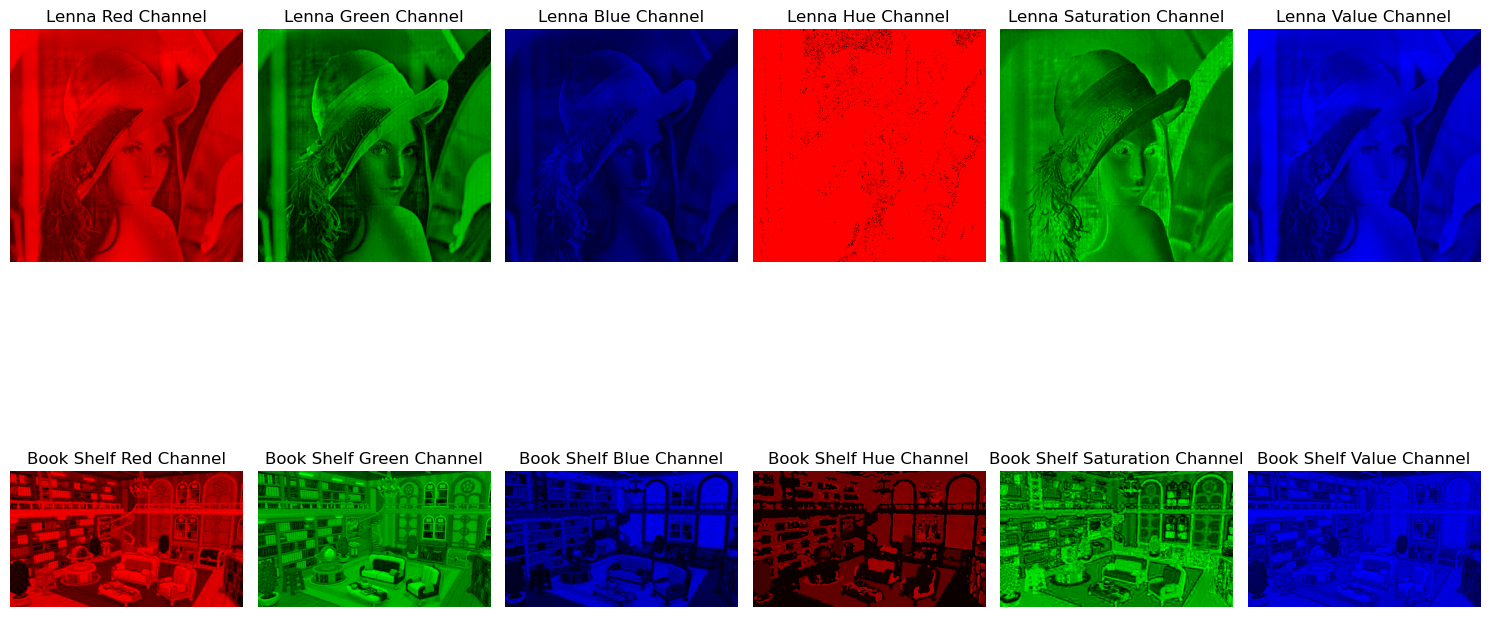

In [48]:
r1_single = extract_single_channel(img1, 0) 
g1_single = extract_single_channel(img1, 1)
b1_single = extract_single_channel(img1, 2) 

r2_single = extract_single_channel(img2, 0)
g2_single = extract_single_channel(img2, 1) 
b2_single = extract_single_channel(img2, 2)  

h1_single = extract_single_channel(img1_hsv, 0) 
s1_single = extract_single_channel(img1_hsv, 1)  
v1_single = extract_single_channel(img1_hsv, 2)

h2_single = extract_single_channel(img2_hsv, 0)  
s2_single = extract_single_channel(img2_hsv, 1)  
v2_single = extract_single_channel(img2_hsv, 2) 

fig, axs = plt.subplots(2, 6, figsize=(15, 10))

axs[0, 0].imshow(r1_single)
axs[0, 0].set_title('Lenna Red Channel')
axs[0, 1].imshow(g1_single)
axs[0, 1].set_title('Lenna Green Channel')
axs[0, 2].imshow(b1_single)
axs[0, 2].set_title('Lenna Blue Channel')

axs[0, 3].imshow(h1_single)
axs[0, 3].set_title('Lenna Hue Channel')
axs[0, 4].imshow(s1_single)
axs[0, 4].set_title('Lenna Saturation Channel')
axs[0, 5].imshow(v1_single)
axs[0, 5].set_title('Lenna Value Channel')

# Book Shelf Image RGB, HSV, CMY Channels
axs[1, 0].imshow(r2_single)
axs[1, 0].set_title('Book Shelf Red Channel')
axs[1, 1].imshow(g2_single)
axs[1, 1].set_title('Book Shelf Green Channel')
axs[1, 2].imshow(b2_single)
axs[1, 2].set_title('Book Shelf Blue Channel')

axs[1, 3].imshow(h2_single)
axs[1, 3].set_title('Book Shelf Hue Channel')
axs[1, 4].imshow(s2_single)
axs[1, 4].set_title('Book Shelf Saturation Channel')
axs[1, 5].imshow(v2_single)
axs[1, 5].set_title('Book Shelf Value Channel')

# Hide axes for all subplots
for ax in axs.flat:
    ax.axis('off')

plt.tight_layout()
plt.show()

In [49]:
def modify_hsv_and_reconstruct(img_hsv, channel_idx=1, multiplier=2):
    img_hsv_mod = np.copy(img_hsv)
    if channel_idx == 1:
        img_hsv_mod[:, :, 1] = np.clip(img_hsv_mod[:, :, 1] * multiplier, 0, 1)
    return img_hsv_mod

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers).


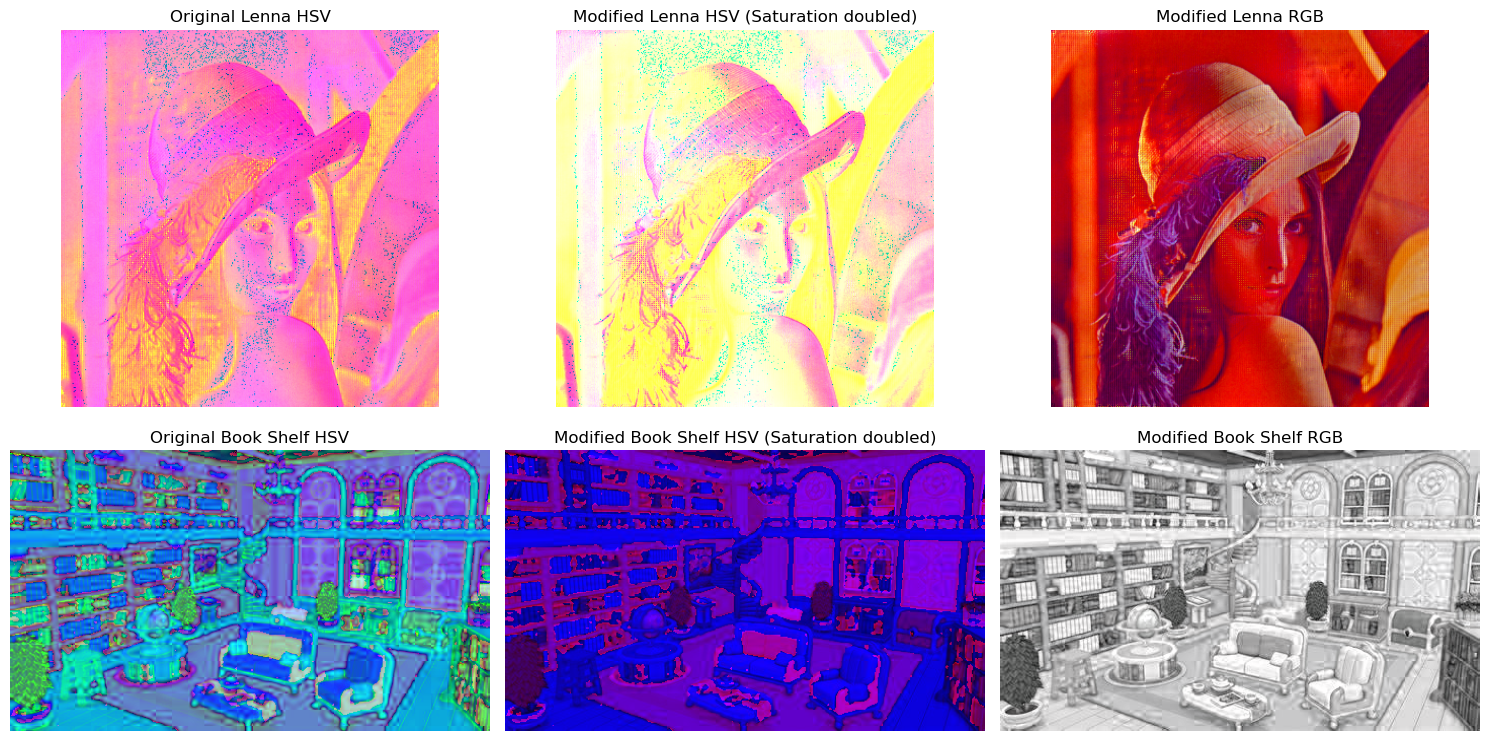

In [50]:
img1_hsv_mod = modify_hsv_and_reconstruct(img1_hsv, 1, 2)
img2_hsv_mod = modify_hsv_and_reconstruct(img2_hsv, 1, 2)

fig, axs = plt.subplots(2, 3, figsize=(15, 8))

axs[0, 0].imshow(img1_hsv)
axs[0, 0].set_title('Original Lenna HSV')
axs[0, 1].imshow(img1_hsv_mod)
axs[0, 1].set_title('Modified Lenna HSV (Saturation doubled)')
axs[0, 2].imshow(cv2.cvtColor(img1_hsv_mod, cv2.COLOR_HSV2RGB))
axs[0, 2].set_title('Modified Lenna RGB')

axs[1, 0].imshow(img2_hsv)
axs[1, 0].set_title('Original Book Shelf HSV')
axs[1, 1].imshow(img2_hsv_mod)
axs[1, 1].set_title('Modified Book Shelf HSV (Saturation doubled)')
axs[1, 2].imshow(cv2.cvtColor(img2_hsv_mod, cv2.COLOR_HSV2RGB))
axs[1, 2].set_title('Modified Book Shelf RGB')

for ax in axs.flat:
    ax.axis('off')

plt.tight_layout()
plt.show()

# EMPTY MATRIX

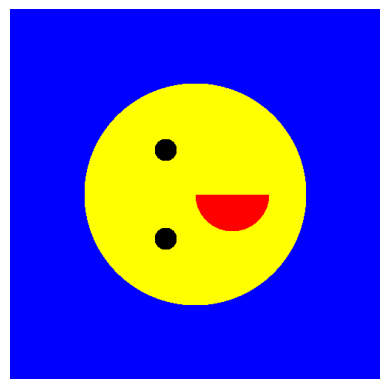

In [51]:
img = np.ones((500, 500, 3))
img[:, :] = [0, 0, 1]

center = (250, 250)
radius = 150
for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        if (i - center[0]) ** 2 + (j - center[1]) ** 2 < radius ** 2:
            img[i, j] = [1, 1, 0]

eye_radius = 15
left_eye_center = (190, 210)
right_eye_center = (310, 210)

for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        if (i - left_eye_center[0]) ** 2 + (j - left_eye_center[1]) ** 2 < eye_radius ** 2:
            img[i, j] = [0, 0, 0]
        if (i - right_eye_center[0]) ** 2 + (j - right_eye_center[1]) ** 2 < eye_radius ** 2:
            img[i, j] = [0, 0, 0]

mouth_radius = 50
mouth_center = (250, 300)
for i in range(img.shape[0]):
    for j in range(img.shape[1]):
        if (i - mouth_center[0]) ** 2 + (j - mouth_center[1]) ** 2 < mouth_radius ** 2 and i > 250:
            img[i, j] = [1, 0, 0]

plt.imshow(img)
plt.axis('off')
plt.show()


In [38]:
image.shape

(3, 1, 3)

In [112]:
s = [255, 153, 51]   # Saffron (RGB to BGR)
w = [255, 255, 255]    # White
g = [19, 136, 8]       # Green
b = [0, 0, 128]
image = np.array([ [s,s,s,s],[w,w,w,w],[g,g,g,g]])

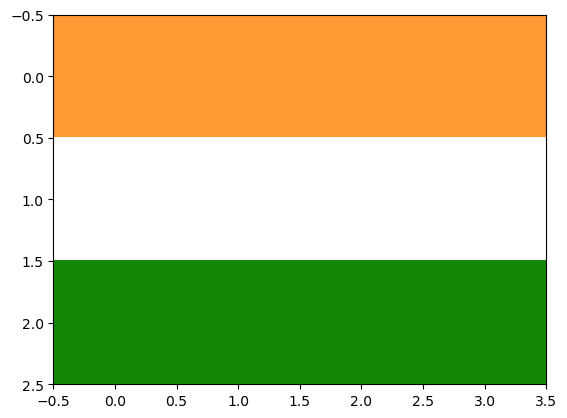

In [113]:
plt.imshow(image)

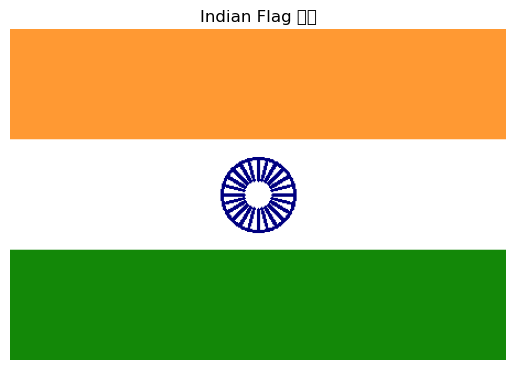

In [114]:
import numpy as np
import matplotlib.pyplot as plt
import cv2

# Define flag dimensions
height = 300  # Total height
width = 450   # Total width
stripe_height = height // 3  # Height of each color stripe

# Create an empty flag with white background
flag = np.ones((height, width, 3), dtype=np.uint8) * 255  

# Define colors (BGR format for OpenCV)
saffron = [51, 153, 255]   # Saffron (RGB to BGR)
white = [255, 255, 255]    # White
green = [8, 136, 19]       # Green
blue = [128, 0, 0]         # Navy Blue (Ashoka Chakra)

# Fill the flag with colors
flag[:stripe_height, :] = saffron   # Top - Saffron
flag[stripe_height:2*stripe_height, :] = white   # Middle - White
flag[2*stripe_height:, :] = green   # Bottom - Green

# Draw Ashoka Chakra (Centered)
center_x, center_y = width // 2, height // 2
radius = stripe_height // 3  # Chakra radius
cv2.circle(flag, (center_x, center_y), radius, blue, thickness=2)  # Outer Circle

# Draw 24 spokes
for angle in range(0, 360, 15):  # 360° / 24 spokes = 15° each
    x1 = int(center_x + radius * np.cos(np.radians(angle)))
    y1 = int(center_y + radius * np.sin(np.radians(angle)))
    x2 = int(center_x + (radius // 2.5) * np.cos(np.radians(angle)))
    y2 = int(center_y + (radius // 2.5) * np.sin(np.radians(angle)))
    cv2.line(flag, (x1, y1), (x2, y2), blue, thickness=2)

# Display the flag
plt.imshow(cv2.cvtColor(flag, cv2.COLOR_BGR2RGB))  # Convert BGR to RGB for correct display
plt.axis("off")  # Hide axes
plt.title("Indian Flag 🇮🇳")
plt.show()
